# Mini Project II - Rotten Tomatoes vs Box Office

Members:
- Anh Nguyen
- Kris Nguyen

## Introduction
Movies are often judged based on ideas and comments from critics and the audience themselves. However, whether those *scores* are fully able to determine whether the films will be a huge success or not is inconclusive.
<br><br>
By combining the datasets, we will analyze trends and relationships between *Rotten Tomatoes scores* and their *box office revenues* through different films. Through this project, we will pinpoint whether these two correlate to each other, in other words, do higher-rated films will be equivalent to higher box office.

### Data Preparation

In [13]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# load datasets
ratings    = pd.read_csv("rotten_tomatoes.csv")
box_office = pd.read_csv("box_office.csv")

In [15]:
# extract and create a new column 'Year' for 'ratings'
ratings['releaseDateTheaters'] = pd.to_datetime(ratings['releaseDateTheaters'])
ratings['Year'] = ratings['releaseDateTheaters'].dt.year

In [16]:
# merge datasets through titles and release year
df = pd.merge(
    ratings,
    box_office,
    left_on=['title', 'Year'],
    right_on=['Release Group', 'Year']
)

### Data Cleaning

In [17]:
# drop rows with NA values
df = df.dropna(subset=['tomatoMeter', '$Worldwide'])

In [18]:
# keep only the columns that we'll be working with
df = df[['title', 'Year', 'tomatoMeter', '$Worldwide']]

## Critics Don't Decide Box Office

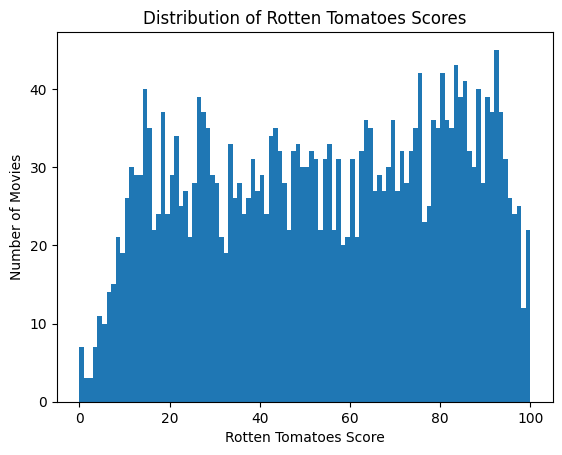

In [19]:
plt.hist(df['tomatoMeter'], bins=100)

plt.xlabel('Rotten Tomatoes Score')
plt.ylabel('Number of Movies')
plt.title('Distribution of Rotten Tomatoes Scores')

plt.show()

## Do Ratings Matter That Much?

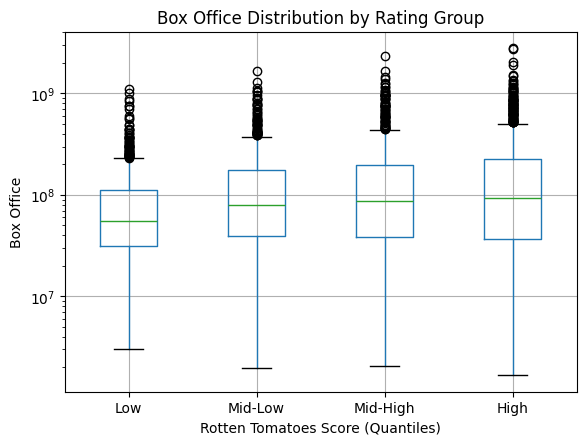

In [23]:
df['group'] = pd.qcut(
    df['tomatoMeter'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

df.boxplot(column='$Worldwide', by='group', showfliers=True)

plt.xlabel('Rotten Tomatoes Score (Quantiles)')
plt.ylabel('Box Office')
plt.title('Box Office Distribution by Rating Group')

plt.suptitle('') 
plt.yscale('log')  

plt.show()